## Examples: An Introduction to NLP and cleaning text

#### In this notebook, we will explore text-cleaning and feature-extraction techniques in NLP. We'll use the NLTK library to preprocess unstructured text data, preparing it for machine learning tasks. By using examples, we'll work through the steps of cleaning text data and extracting meaningful features

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Gain a basic understanding of text-cleaning techniques
#### - Implement text-cleaning steps such as removing URLs, converting test to lowercase, and removing punctuation
#### - Understand the concept of tokenisation and its importance in text processing
#### - Apply stemming and lemmatization to reduce words to their root forms
#### - Demonstrate the removal of stop words and their impact on text analysis

In [1]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re

# set plot style
sns.set_theme()

In [2]:
# Download NLTK corpora
# nltk.download(['punkt', 'stopwords'])
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [3]:
nltk.data.path.append("D:/ALX/Data Science/Machine Learning/NLP and Classification/Natural Language Processing 2.0/NLTK Downloads Folder")

In [4]:
from nltk.corpus import stopwords

In [5]:
stopwords_list = stopwords.words('english')
print(stopwords_list)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [6]:
# Read the MBTI dataset
mbti = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/mbti_train.csv')
mbti.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [7]:
# print list of unique MBTI personality types
type_labels = list(mbti.type.unique())
print(type_labels)

['INFJ', 'ENTP', 'INTP', 'INTJ', 'ENTJ', 'ENFJ', 'INFP', 'ENFP', 'ISFP', 'ISTP', 'ISFJ', 'ISTJ', 'ESTP', 'ESFP', 'ESTJ', 'ESFJ']


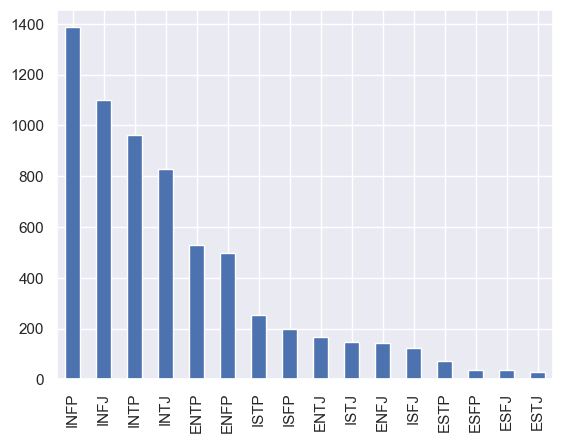

In [9]:
# visualise the distribution of MBTI personality types
mbti['type'].value_counts().plot(kind='bar')
plt.show()

In [10]:
# separate each post in the 'posts' column into its own row
all_mbti = []
for i, row in mbti.iterrows():
    for post in row['posts'].split('|||'):
        all_mbti.append([row['type'], post])
all_mbti = pd.DataFrame(all_mbti, columns=['type', 'post'])

In [11]:
all_mbti.shape

(316548, 2)

<AxesSubplot:>

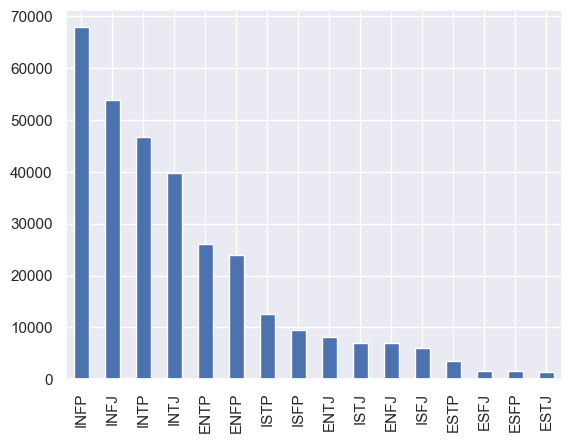

In [16]:
all_mbti['type'].value_counts().plot(kind='bar')

## Text Cleaning

In [17]:
# Replace URLs in the 'post' column with a placeholder string
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
all_mbti['post'] = all_mbti['post'].replace(
    to_replace = pattern_url, value= subs_url, regex=True
)

In [18]:
all_mbti.head()

,type,post
0,INFJ,'url-web
1,INFJ,url-web
2,INFJ,enfp and intj moments url-web sportscenter n...
3,INFJ,What has been the most life-changing experienc...
4,INFJ,url-web url-web On repeat for most of today.


### Remove Punctuation

In [19]:
all_mbti['post'] = all_mbti['post'].str.lower()

In [21]:
import string
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [22]:
def remove_punctuation(post):
    return ''.join([l for l in post if l not in string.punctuation])

In [31]:
all_mbti['post'] = all_mbti['post'].apply(remove_punctuation)
all_mbti['post'].iloc[268558]

'just when i think i’ve lost you just when i’m so tired i toss away the fight and say “i’ll just embrace my demons then… ‘cause you feel so far away and i’ll never be your angel” —that’s when'

### Tokenisation

In [32]:
from nltk.tokenize import word_tokenize, TreebankWordTokenizer

In [33]:
word_tokenize('A tokenizer divides text into a sequence of tokens, which roughly correspond to "words".')

['A',
 'tokenizer',
 'divides',
 'text',
 'into',
 'a',
 'sequence',
 'of',
 'tokens',
 ',',
 'which',
 'roughly',
 'correspond',
 'to',
 '``',
 'words',
 "''",
 '.']

In [34]:
# Tokenize the text using the TreebankWordTokenizer
tokeniser = TreebankWordTokenizer()
all_mbti['tokens'] = all_mbti['post'].apply(tokeniser.tokenize)

In [45]:
all_mbti['tokens'].iloc[55555]

['i',
 'find',
 'all',
 'of',
 'you',
 'to',
 'be',
 'extremely',
 'humorous',
 'now',
 'to',
 'find',
 'other',
 'specimen',
 'to',
 'observe']

### Stemming

In [46]:
from nltk import SnowballStemmer, PorterStemmer, LancasterStemmer

In [47]:
words = 'caring cares cared caringly carefully'

In [48]:
# find the stem of each word in words
stemmer = SnowballStemmer('english')
for word in words.split():
    print(stemmer.stem(word))

care
care
care
care
care


In [49]:
def mbti_stemmer(words, stemmer):
    return [stemmer.stem(word) for word in words]

In [52]:
all_mbti['stem'] = all_mbti['tokens'].apply(mbti_stemmer, args=(stemmer,))

In [54]:
for i, t in enumerate(all_mbti.iloc[268702]['tokens']):
    print('{:20s} --> {:10s}'.format(t, all_mbti.iloc[268702]['stem'][i]))

i                    --> i         
hate                 --> hate      
april                --> april     
fools                --> fool      
day                  --> day       
angry                --> angri     
theres               --> there     
a                    --> a         
site                 --> site      
im                   --> im        
regularly            --> regular   
on                   --> on        
and                  --> and       
the                  --> the       
admins               --> admin     
are                  --> are       
screwing             --> screw     
everything           --> everyth   
up                   --> up        
today                --> today     
for                  --> for       
a                    --> a         
laugh                --> laugh     
but                  --> but       
i                    --> i         
dont                 --> dont      
find                 --> find      
it                   --> it 

### Lemmatization

In [56]:
from nltk.stem import WordNetLemmatizer
nltk.download(['wordnet', 'omw-1.4'])

lemmatizer = WordNetLemmatizer()

print(lemmatizer.lemmatize("cats"))
print(lemmatizer.lemmatize("cacti"))
print(lemmatizer.lemmatize("geese"))
print(lemmatizer.lemmatize("rocks"))
print(lemmatizer.lemmatize("python"))
print(lemmatizer.lemmatize("better", pos="a"))
print(lemmatizer.lemmatize("best", pos="a"))
print(lemmatizer.lemmatize("run"))
print(lemmatizer.lemmatize("ran", 'v'))

[nltk_data] Downloading package wordnet to D:\ALX\Data Science\Machine
[nltk_data]     Learning\NLP and Classification\Natural Language
[nltk_data]     Processing 2.0\NLTK Downloads Folder...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to D:\ALX\Data Science\Machine
[nltk_data]     Learning\NLP and Classification\Natural Language
[nltk_data]     Processing 2.0\NLTK Downloads Folder...


cat
cactus
goose
rock
python
good
best
run
run


In [57]:
def mbti_lemma(words, lemmatizer):
    return [lemmatizer.lemmatize(word) for word in words]

In [58]:
all_mbti['lemma'] = all_mbti['tokens'].apply(mbti_lemma, args=(lemmatizer,))

In [59]:
for i, t in enumerate(all_mbti.iloc[268702]['tokens']):
    print('{:20s} --> {:10s}'.format(t, all_mbti.iloc[268702]['lemma'][i]))

i                    --> i         
hate                 --> hate      
april                --> april     
fools                --> fool      
day                  --> day       
angry                --> angry     
theres               --> there     
a                    --> a         
site                 --> site      
im                   --> im        
regularly            --> regularly 
on                   --> on        
and                  --> and       
the                  --> the       
admins               --> admins    
are                  --> are       
screwing             --> screwing  
everything           --> everything
up                   --> up        
today                --> today     
for                  --> for       
a                    --> a         
laugh                --> laugh     
but                  --> but       
i                    --> i         
dont                 --> dont      
find                 --> find      
it                   --> it 

### Stop words

In [64]:
from nltk.corpus import stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [65]:
sorted(stopwords.words('english'))[0:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [66]:
def remove_stop_words(tokens):
    return [t for t in tokens if t not in stopwords.words('english')]

In [67]:
all_mbti['stem'] = all_mbti['tokens'].apply(remove_stop_words)
all_mbti['stem']

0                                                  [urlweb]
1                                                  [urlweb]
2         [enfp, intj, moments, urlweb, sportscenter, to...
3                          [lifechanging, experience, life]
4                           [urlweb, urlweb, repeat, today]
                                ...                        
316543    [kallinhausin, may, rooted, problem, infps, pr...
316544    [regards, king, show, book, havent, read, book...
316545         [sunlight, bouncing, fog, dawn, serendipity]
316546                            [songs, really, powerful]
316547                     [remember, werent, trying, hurt]
Name: stem, Length: 316548, dtype: object